In [1]:
import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/model_outputs/predictions/labeled_continuations.csv')

## Confirming heuristic for gap classification based on first token POS

In [3]:
clean_df = df[df['label'] != 'unclear']

counts = clean_df.groupby(['continuation_start_pos', 'label']).size().unstack(fill_value=0)
counts['total'] = counts.sum(axis=1)
pcts = counts[['gap', 'no_gap']].div(counts['total'], axis=0).mul(100).round(1)

combined = counts.copy()
combined['pct_gap']    = pcts['gap']
combined['pct_no_gap'] = pcts['no_gap']

combined = combined[['gap', 'pct_gap', 'no_gap', 'pct_no_gap', 'total']]
combined.index.name = 'pos'

print("=== POS BY GAP vs NO_GAP (Continuations) ===")
print(combined)

=== POS BY GAP vs NO_GAP (Continuations) ===
label  gap  pct_gap  no_gap  pct_no_gap  total
pos                                           
ADJ      0      0.0       2       100.0      2
ADP     39     95.1       2         4.9     41
ADV      3     75.0       1        25.0      4
AUX      1    100.0       0         0.0      1
CCONJ   11     84.6       2        15.4     13
DET      0      0.0      26       100.0     26
NOUN     0      0.0       4       100.0      4
NUM      0      0.0       2       100.0      2
PRON     0      0.0      53       100.0     53
PROPN    0      0.0       2       100.0      2
PUNCT   61     96.8       2         3.2     63
SCONJ    7    100.0       0         0.0      7
SYM      0      0.0       3       100.0      3


In [4]:
 def compute_stats(data):
        total        = len(data)
        n_unclear    = (data['label'] == 'unclear').sum()
        pct_unclear  = round(n_unclear / total * 100, 1)

        # exclude unclear for grammaticality and congruence
        clear = data[data['label'] != 'unclear']
        n_clear = len(clear)

        if n_clear == 0:
            return {'total': total, 'pct_unclear': pct_unclear,
                    'pct_grammatical': None, 'pct_congruent': None}

        n_grammatical   = (clear['grammaticality'] == 'grammatical').sum()
        pct_grammatical = round(n_grammatical / n_clear * 100, 1)

        n_congruent     = (clear['label'] == clear['expected']).sum()
        pct_congruent   = round(n_congruent / n_clear * 100, 1)

        return {
            'total':            total,
            'n_unclear':        n_unclear,
            'pct_unclear':      pct_unclear,
            'n_grammatical':    n_grammatical,
            'pct_grammatical':  pct_grammatical,
            'n_congruent':      n_congruent,
            'pct_congruent':    pct_congruent,
        }

## Congruence & correct predictions analysis

In [5]:
def analyse_continuations(df, model):
    """
    For a given model, prints % grammatical/congruent/unclear,
    aggregated and split by condition.
    Unclear sentences are excluded from congruence and grammaticality analysis.
    Args:
        df: dataframe of labelled continuations
        model: model name string e.g. 'gpt2' or 'grnn'
    """
    model_df = df[df['model'] == model].copy()
    model_df['expected'] = model_df['condition'].apply(
        lambda c: 'no_gap' if c.endswith('no_gap') else 'gap'
    )

    print(f"=== {model.upper()} — AGGREGATED ===")
    stats = compute_stats(model_df)
    for k, v in stats.items():
        print(f"  {k}: {v}")

    print(f"\n=== {model.upper()} — BY CONDITION ===")
    for condition, group in model_df.groupby('condition'):
        print(f"\n  {condition}:")
        stats = compute_stats(group)
        for k, v in stats.items():
            print(f"    {k}: {v}")

    print(f"\n=== {model.upper()} — BY GRAMMATICALITY (excluding unclear) ===")
    clear_df = model_df[model_df['label'] != 'unclear'].copy()
    for gramm, group in clear_df.groupby('grammaticality'):
        n   = len(group)
        pct = round(n / len(clear_df) * 100, 1)
        print(f"\n  {gramm} ({n} sentences, {pct}% of clear):")
        for condition, cond_group in group.groupby('condition'):
            print(f"    {condition}: {len(cond_group)}")

    print(f"\n=== {model.upper()} — BY CONGRUENCE (excluding unclear) ===")
    clear_df['congruent'] = clear_df['label'] == clear_df['expected']
    for congr, group in clear_df.groupby('congruent'):
        label = 'congruent' if congr else 'incongruent'
        n     = len(group)
        pct   = round(n / len(clear_df) * 100, 1)
        print(f"\n  {label} ({n} sentences, {pct}% of clear):")
        for condition, cond_group in group.groupby('condition'):
            print(f"    {condition}: {len(cond_group)}")

    print(f"\n=== {model.upper()} — BY GRAMMATICALITY x CONGRUENCE (excluding unclear) ===")
    clear_df['congruent'] = clear_df['label'] == clear_df['expected']
    cross = clear_df.groupby(['grammaticality', 'congruent']).size().unstack(fill_value=0)
    cross.columns = ['incongruent', 'congruent']
    cross['total'] = cross.sum(axis=1)
    cross['pct_congruent'] = (cross['congruent'] / cross['total'] * 100).round(1)
    print(cross)

In [6]:
analyse_continuations(df, 'gpt2')

=== GPT2 — AGGREGATED ===
  total: 120
  n_unclear: 1
  pct_unclear: 0.8
  n_grammatical: 103
  pct_grammatical: 86.6
  n_congruent: 101
  pct_congruent: 84.9

=== GPT2 — BY CONDITION ===

  +wh_gap:
    total: 60
    n_unclear: 1
    pct_unclear: 1.7
    n_grammatical: 44
    pct_grammatical: 74.6
    n_congruent: 44
    pct_congruent: 74.6

  -wh_no_gap:
    total: 60
    n_unclear: 0
    pct_unclear: 0.0
    n_grammatical: 59
    pct_grammatical: 98.3
    n_congruent: 57
    pct_congruent: 95.0

=== GPT2 — BY GRAMMATICALITY (excluding unclear) ===

  grammatical (103 sentences, 86.6% of clear):
    +wh_gap: 44
    -wh_no_gap: 59

  ungrammatical (16 sentences, 13.4% of clear):
    +wh_gap: 15
    -wh_no_gap: 1

=== GPT2 — BY CONGRUENCE (excluding unclear) ===

  incongruent (18 sentences, 15.1% of clear):
    +wh_gap: 15
    -wh_no_gap: 3

  congruent (101 sentences, 84.9% of clear):
    +wh_gap: 44
    -wh_no_gap: 57

=== GPT2 — BY GRAMMATICALITY x CONGRUENCE (excluding unclear) ==

In [7]:
analyse_continuations(df, 'grnn')

=== GRNN — AGGREGATED ===
  total: 120
  n_unclear: 18
  pct_unclear: 15.0
  n_grammatical: 74
  pct_grammatical: 72.5
  n_congruent: 73
  pct_congruent: 71.6

=== GRNN — BY CONDITION ===

  +wh_gap:
    total: 60
    n_unclear: 6
    pct_unclear: 10.0
    n_grammatical: 48
    pct_grammatical: 88.9
    n_congruent: 50
    pct_congruent: 92.6

  -wh_no_gap:
    total: 60
    n_unclear: 12
    pct_unclear: 20.0
    n_grammatical: 26
    pct_grammatical: 54.2
    n_congruent: 23
    pct_congruent: 47.9

=== GRNN — BY GRAMMATICALITY (excluding unclear) ===

  grammatical (74 sentences, 72.5% of clear):
    +wh_gap: 48
    -wh_no_gap: 26

  ungrammatical (28 sentences, 27.5% of clear):
    +wh_gap: 6
    -wh_no_gap: 22

=== GRNN — BY CONGRUENCE (excluding unclear) ===

  incongruent (29 sentences, 28.4% of clear):
    +wh_gap: 4
    -wh_no_gap: 25

  congruent (73 sentences, 71.6% of clear):
    +wh_gap: 50
    -wh_no_gap: 23

=== GRNN — BY GRAMMATICALITY x CONGRUENCE (excluding unclear) =

In [8]:
def plot_continuation_analysis(df, models=('gpt2', 'grnn')):
    metrics      = ['pct_unclear', 'pct_grammatical', 'pct_congruent']
    labels       = ['Unclear', 'Grammatical', 'Congruent']
    model_colors = {'gpt2': '#5bbcd6', 'grnn': '#f98400'}

    all_stats = {}
    for model in models:
        model_df = df[df['model'] == model].copy()
        model_df['expected'] = model_df['condition'].apply(
            lambda c: 'no_gap' if c.endswith('no_gap') else 'gap'
        )
        all_stats[model] = compute_stats(model_df)

    x       = np.arange(len(metrics))
    width   = 0.3
    n       = len(models)
    offsets = np.linspace(-(n - 1) / 2, (n - 1) / 2, n) * width

    fig, ax = plt.subplots(figsize=(7, 4))

    for i, model in enumerate(models):
        values = [all_stats[model][m] for m in metrics]
        bars   = ax.bar(x + offsets[i], values, width, alpha=0.85,
                        color=model_colors.get(model, '#aaaaaa'),
                        edgecolor='white', linewidth=0.5)
        for bar, val in zip(bars, values):
            if val is not None:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.5,
                    f'{model}\n{val}%',
                    ha='center', va='bottom', fontsize=7.5
                )

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel('Percentage (%)')
    ax.set_title('Continuation Analysis by Model')
    ax.set_ylim(0, 110)
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend().set_visible(False)

    plt.tight_layout()
    plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


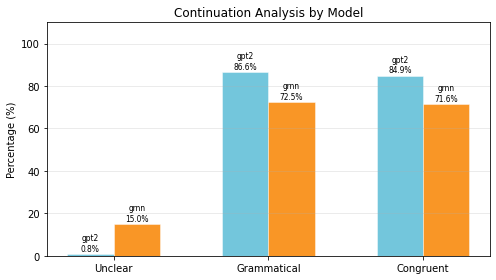

In [9]:
plot_continuation_analysis(df)

### grammaticality per model and embedding level

In [10]:
def plot_grammaticality_by_embedding(df, models=('gpt2', 'grnn')):
    """
    Plots % grammatical continuations per model per embedding level,
    excluding unclear sentences.

    Args:
        df: dataframe of labelled continuations
        models: tuple of model names to plot
    """
    model_colors = {'gpt2': '#5bbcd6', 'grnn': '#f98400'}
    embedding_levels = sorted(df['embedding_level'].unique())

    x       = np.arange(len(embedding_levels))
    width   = 0.3
    n       = len(models)
    offsets = np.linspace(-(n - 1) / 2, (n - 1) / 2, n) * width

    fig, ax = plt.subplots(figsize=(8, 4))

    for i, model in enumerate(models):
        model_df = df[(df['model'] == model) & (df['label'] != 'unclear')]
        values   = []
        for level in embedding_levels:
            level_df      = model_df[model_df['embedding_level'] == level]
            pct_gramm     = round((level_df['grammaticality'] == 'grammatical').sum() / len(level_df) * 100, 1) if len(level_df) > 0 else None
            values.append(pct_gramm)

        bars = ax.bar(x + offsets[i], values, width, alpha=0.85,
                      color=model_colors.get(model, '#aaaaaa'),
                      edgecolor='white', linewidth=0.5)
        for bar, val in zip(bars, values):
            if val is not None:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.5,
                    f'{model}\n{val}%',
                    ha='center', va='bottom', fontsize=7.5
                )

    ax.set_xticks(x)
    ax.set_xticklabels([f'embedding {l}' for l in embedding_levels])
    ax.set_ylabel('% Grammatical')
    ax.set_xlabel('Embedding Level')
    ax.set_title('Grammaticality by Model and Embedding Level')
    ax.set_ylim(0, 110)
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend().set_visible(False)
    
    plt.savefig('../data/images/hand_labeled_grammaticality.png', dpi=300, bbox_inches='tight')
    plt.tight_layout()
    plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


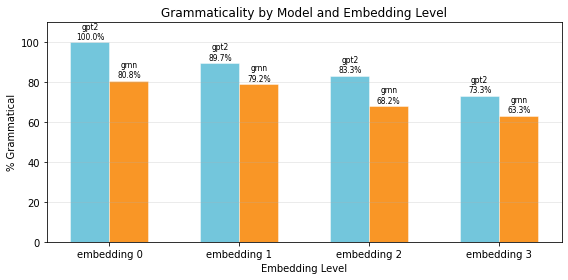

In [11]:
plot_grammaticality_by_embedding(df, models=('gpt2', 'grnn'))

## congruence per model x embedding level

In [12]:
def plot_congruence_by_embedding(df, models=('gpt2', 'grnn')):
    """
    Plots % congruent continuations per model per embedding level,
    excluding unclear sentences.

    Args:
        df: dataframe of labelled continuations
        models: tuple of model names to plot
    """
    model_colors = {'gpt2': '#5bbcd6', 'grnn': '#f98400'}
    embedding_levels = sorted(df['embedding_level'].unique())

    x       = np.arange(len(embedding_levels))
    width   = 0.3
    n       = len(models)
    offsets = np.linspace(-(n - 1) / 2, (n - 1) / 2, n) * width

    fig, ax = plt.subplots(figsize=(8, 4))

    for i, model in enumerate(models):
        model_df = df[(df['model'] == model) & (df['label'] != 'unclear')].copy()
        model_df['expected'] = model_df['condition'].apply(
            lambda c: 'no_gap' if c.endswith('no_gap') else 'gap'
        )
        values = []
        for level in embedding_levels:
            level_df    = model_df[model_df['embedding_level'] == level]
            pct_congr   = round((level_df['label'] == level_df['expected']).sum() / len(level_df) * 100, 1) if len(level_df) > 0 else None
            values.append(pct_congr)

        bars = ax.bar(x + offsets[i], values, width, alpha=0.85,
                      color=model_colors.get(model, '#aaaaaa'),
                      edgecolor='white', linewidth=0.5)
        for bar, val in zip(bars, values):
            if val is not None:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.5,
                    f'{model}\n{val}%',
                    ha='center', va='bottom', fontsize=7.5
                )

    ax.set_xticks(x)
    ax.set_xticklabels([f'embedding {l}' for l in embedding_levels])
    ax.set_ylabel('% Correctly predicted')
    ax.set_xlabel('Embedding Level')
    ax.set_title('Gap prediction in generated sentences by Model and Embedding Level')
    ax.set_ylim(0, 110)
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend().set_visible(False)

    plt.tight_layout()
    plt.savefig('../data/images/hand_labeled_congruence.png', dpi=300, bbox_inches='tight')
    plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


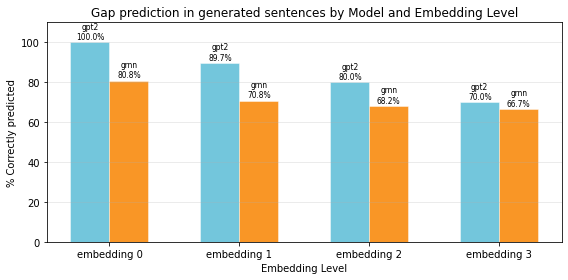

In [13]:
plot_congruence_by_embedding(df, models=('gpt2', 'grnn'))